In [42]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import CategoricalNB

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

1. Data Preprocessing:
* Load the dataset and separate the input features (Outlook, Temperature, Humidity, Wind) from the target variable (Play).
* Convert all categorical feature values and target labels into numerical representations using an appropriate encoding technique.

In [43]:
# Load dataset
df = pd.read_excel("Lab 8.xlsx")

# Check column names
print(df.columns)

# Separate features and target
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['Play Tennis']

# Create encoders
outlook_encoder = LabelEncoder()
temperature_encoder = LabelEncoder()
humidity_encoder = LabelEncoder()
wind_encoder = LabelEncoder()
play_encoder = LabelEncoder()

# Encode features
X['Outlook'] = outlook_encoder.fit_transform(X['Outlook'])
X['Temperature'] = temperature_encoder.fit_transform(X['Temperature'])
X['Humidity'] = humidity_encoder.fit_transform(X['Humidity'])
X['Wind'] = wind_encoder.fit_transform(X['Wind'])

# Encode target
y = play_encoder.fit_transform(y)

# Display results
print("Encoded Features:")
print(X.head())

print("\nEncoded Target:")
print(y)

Index(['No', 'Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis'], dtype='object')
Encoded Features:
   Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1

Encoded Target:
[0 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1
 1 1 1 0 0 1 0 1 1 1 0 1 1]


/tmp/ipykernel_1352/2918536784.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Outlook'] = outlook_encoder.fit_transform(X['Outlook'])
/tmp/ipykernel_1352/2918536784.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Temperature'] = temperature_encoder.fit_transform(X['Temperature'])
/tmp/ipykernel_1352/2918536784.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

2.Dataset Partitioning:
* Divide the dataset into training and testing subsets using an 80:20 train-test split ratio.


In [44]:
# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the datasets
print("Training Features:")
print(X_train)

print("\nTesting Features:")
print(X_test)

print("\nTraining Labels:")
print(y_train)

print("\nTesting Labels:")
print(y_test)

# Display dataset sizes
print("\nTraining Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features:
    Outlook  Temperature  Humidity  Wind
12        0            1         1     1
4         1            0         1     1
37        0            2         0     1
8         2            0         1     1
3         1            2         0     1
6         0            0         1     0
41        2            0         0     1
46        1            2         1     1
47        1            0         0     0
15        2            0         0     0
9         1            2         1     1
16        2            1         1     1
24        1            1         1     1
34        0            1         0     0
31        2            1         0     1
0         2            1         0     1
44        0            0         0     1
27        1            0         0     0
33        2            2         1     1
5         1            0         1     0
29        2            2         0     0
11        0            2         0     0
36        0            0         1    

3. Naive Bayes Model Training & Evaluation:
*  Train a Categorical Naive Bayes (CategoricalNB) model on the training data.
*  Predict the class labels for the test dataset.
*  Calculate and display the overall Model Accuracy.
*  Display the Confusion Matrix and Classification Report (Precision, Recall, F1-Score).

Predicted Class Labels:
[0 1 1 1 1 1 0 1 1 1]

Model Accuracy: 0.8
Model Accuracy: 80.00%

Confusion Matrix:
[[1 1]
 [1 7]]


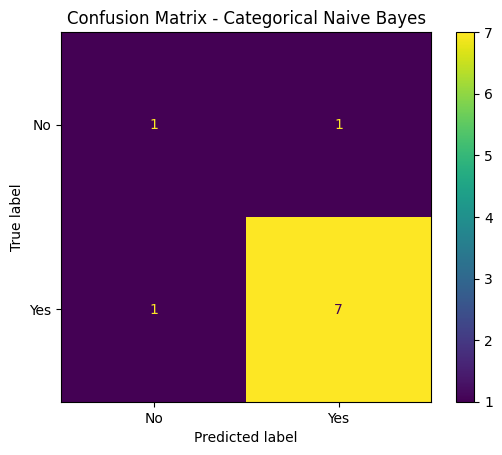


Classification Report:

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10


Class Probabilities:
[[0.53454187 0.46545813]
 [0.10092291 0.89907709]
 [0.49682977 0.50317023]
 [0.00967104 0.99032896]
 [0.43438177 0.56561823]
 [0.21913383 0.78086617]
 [0.58581346 0.41418654]
 [0.23500073 0.76499927]
 [0.17916197 0.82083803]
 [0.34776743 0.65223257]]

Probability Table:
         No       Yes
0  0.534542  0.465458
1  0.100923  0.899077
2  0.496830  0.503170
3  0.009671  0.990329
4  0.434382  0.565618
5  0.219134  0.780866
6  0.585813  0.414187
7  0.235001  0.764999
8  0.179162  0.820838
9  0.347767  0.652233


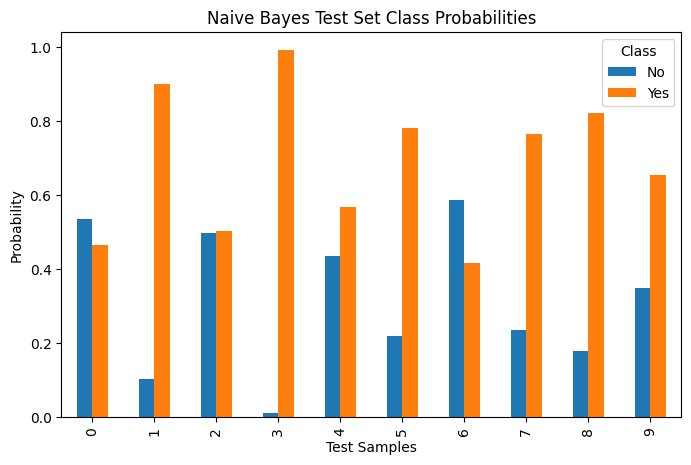

In [45]:
# -------------------------------
# 3.1 Train the Naive Bayes Model
# -------------------------------

nb_model = CategoricalNB()

nb_model.fit(X_train, y_train)

# -------------------------------
# 3.2 Predict Test Dataset
# -------------------------------

y_pred = nb_model.predict(X_test)

print("Predicted Class Labels:")
print(y_pred)

# -------------------------------
# 3.3 Calculate Model Accuracy
# -------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("Model Accuracy: {:.2f}%".format(accuracy*100))

# -------------------------------
# 3.4 Confusion Matrix
# -------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=play_encoder.classes_
)

plt.title("Confusion Matrix - Categorical Naive Bayes")
plt.show()

# -------------------------------
# 3.5 Classification Report
# -------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=play_encoder.classes_
    )
)

# -------------------------------
# 3.6 Predict Class Probabilities
# (Optional but useful)
# -------------------------------

y_prob = nb_model.predict_proba(X_test)

print("\nClass Probabilities:")
print(y_prob)

# Display probabilities in table format

prob_df = pd.DataFrame(
    y_prob,
    columns=play_encoder.classes_
)

print("\nProbability Table:")
print(prob_df)

# -------------------------------
# 3.7 Visualize Probabilities
# (Optional)
# -------------------------------

prob_df.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Naive Bayes Test Set Class Probabilities")
plt.xlabel("Test Samples")
plt.ylabel("Probability")
plt.legend(title="Class")
plt.show()

4. Single-Sample Inference:

* Predict whether a person will play tennis under the following specific weather conditions:

   1.   Outlook: Sunny
   2.   Temperature: Cool
   1.   Humidity: High
   2.   Wind: Strong

* Display both the predicted class label and the corresponding class
probabilities


Predicted Class Label: No

Class Probabilities:
No: 0.9256
Yes: 0.0744


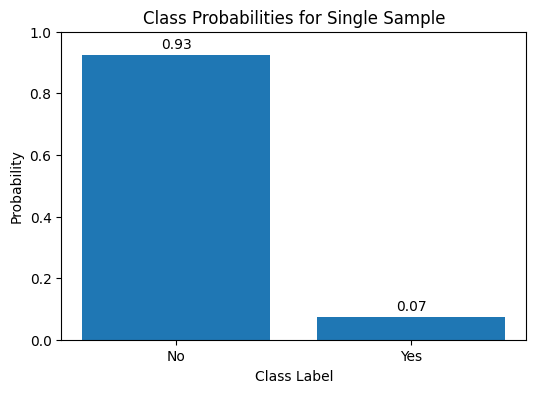

In [46]:
# Create a new sample
sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

# Encode the sample
sample['Outlook'] = outlook_encoder.transform(sample['Outlook'])
sample['Temperature'] = temperature_encoder.transform(sample['Temperature'])
sample['Humidity'] = humidity_encoder.transform(sample['Humidity'])
sample['Wind'] = wind_encoder.transform(sample['Wind'])

# Predict class label
prediction = nb_model.predict(sample)

# Convert prediction back to original label
predicted_label = play_encoder.inverse_transform(prediction)

print("Predicted Class Label:", predicted_label[0])

# Predict class probabilities
probabilities = nb_model.predict_proba(sample)

print("\nClass Probabilities:")
for label, prob in zip(play_encoder.classes_, probabilities[0]):
    print(f"{label}: {prob:.4f}")

# Plot probabilities
classes = play_encoder.classes_
probs = probabilities[0]

plt.figure(figsize=(6,4))
plt.bar(classes, probs)

plt.title("Class Probabilities for Single Sample")
plt.xlabel("Class Label")
plt.ylabel("Probability")

for i, prob in enumerate(probs):
    plt.text(i, prob + 0.02, f"{prob:.2f}", ha='center')

plt.ylim(0,1)
plt.show()

5. Model Comparison:

*  Train a Decision Tree Classifier and a Logistic Regression Classifier, and an SVM on the same training data.
*  Compare all three models in terms of test accuracy, single-sample query prediction, and output class probabilities


Step 5.1: Train the Decision Tree Classifier

In [47]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

dt_label = play_encoder.inverse_transform(dt_model.predict(sample))

dt_prob = dt_model.predict_proba(sample)

print("Decision Tree Accuracy:", dt_accuracy)
print("Prediction:", dt_label[0])
print("Probabilities:", dt_prob)

Decision Tree Accuracy: 0.8
Prediction: No
Probabilities: [[1. 0.]]


Step 5.2: Train the Logistic Regression Classifier

In [48]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

lr_label = play_encoder.inverse_transform(lr_model.predict(sample))

lr_prob = lr_model.predict_proba(sample)

print("\nLogistic Regression Accuracy:", lr_accuracy)
print("Prediction:", lr_label[0])
print("Probabilities:", lr_prob)


Logistic Regression Accuracy: 0.4
Prediction: No
Probabilities: [[0.94392742 0.05607258]]


Step 5.3: Train the SVM Classifier

In [49]:
svm_model = SVC(probability=True, random_state=42)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

svm_label = play_encoder.inverse_transform(svm_model.predict(sample))

svm_prob = svm_model.predict_proba(sample)

print("\nSVM Accuracy:", svm_accuracy)
print("Prediction:", svm_label[0])
print("Probabilities:", svm_prob)


SVM Accuracy: 0.7
Prediction: No
Probabilities: [[0.97514137 0.02485863]]


Step 5.5: Display Results

In [50]:
print("\nDecision Tree")
print("Prediction:", dt_label[0])
print("Probabilities:", dt_prob)

print("\nLogistic Regression")
print("Prediction:", lr_label[0])
print("Probabilities:", lr_prob)

print("\nSVM")
print("Prediction:", svm_label[0])
print("Probabilities:", svm_prob)


Decision Tree
Prediction: No
Probabilities: [[1. 0.]]

Logistic Regression
Prediction: No
Probabilities: [[0.94392742 0.05607258]]

SVM
Prediction: No
Probabilities: [[0.97514137 0.02485863]]


Step 5.6: Compare All Models


Comparison Table
                 Model  Accuracy Prediction
0          Naive Bayes       0.8         No
1        Decision Tree       0.8         No
2  Logistic Regression       0.4         No
3                  SVM       0.7         No

Probability Comparison
                 Model  Probability (No)  Probability (Yes)
0          Naive Bayes          0.925602           0.074398
1        Decision Tree          1.000000           0.000000
2  Logistic Regression          0.943927           0.056073
3                  SVM          0.975141           0.024859


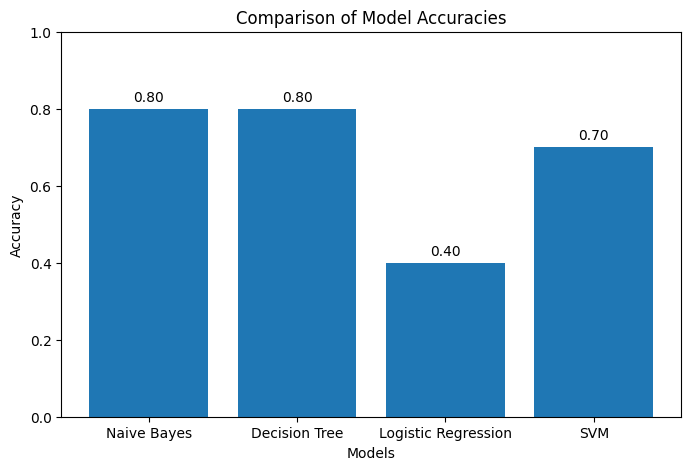

In [51]:
comparison = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Decision Tree",
        "Logistic Regression",
        "SVM"
    ],

    "Accuracy":[
        accuracy,
        dt_accuracy,
        lr_accuracy,
        svm_accuracy
    ],

    "Prediction":[
        predicted_label[0],
        dt_label[0],
        lr_label[0],
        svm_label[0]
    ]
})

print("\nComparison Table")
print(comparison)


# ==========================================
# 5.5 Probability Comparison Table
# ==========================================

probability_table = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Decision Tree",
        "Logistic Regression",
        "SVM"
    ],

    "Probability (No)":[
        probabilities[0][0],
        dt_prob[0][0],
        lr_prob[0][0],
        svm_prob[0][0]
    ],

    "Probability (Yes)":[
        probabilities[0][1],
        dt_prob[0][1],
        lr_prob[0][1],
        svm_prob[0][1]
    ]

})

print("\nProbability Comparison")
print(probability_table)


# ==========================================
# 5.6 Plot Model Accuracy
# ==========================================

models = comparison["Model"]
accuracies = comparison["Accuracy"]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.title("Comparison of Model Accuracies")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0,1)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.02,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.show()
plt.show()